### TP3 - Traitement des images 
Sharaine MALARVIJY 21206543

In [1]:
from TP3 import *

## Exercice 1

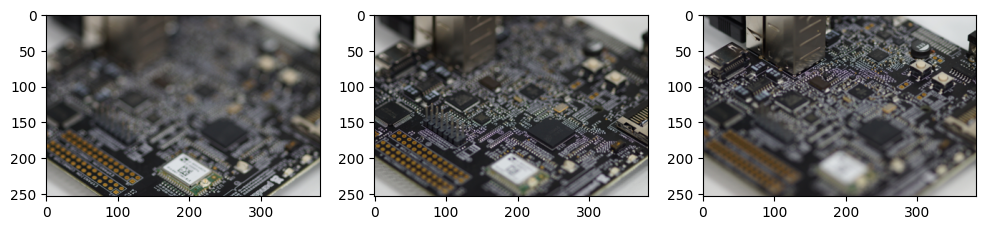

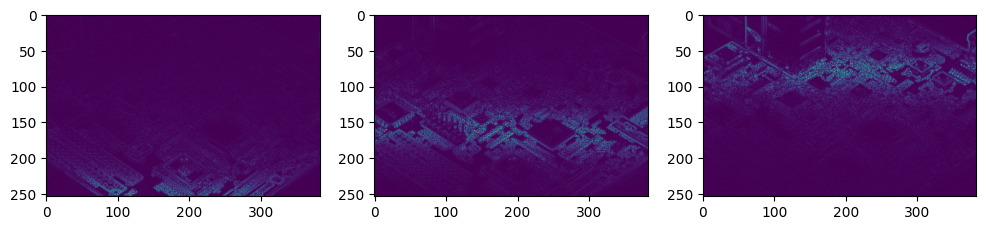

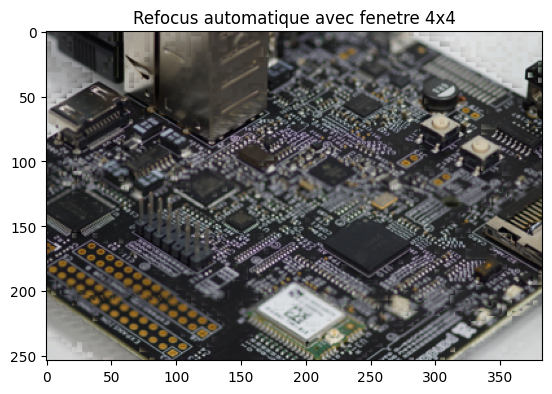

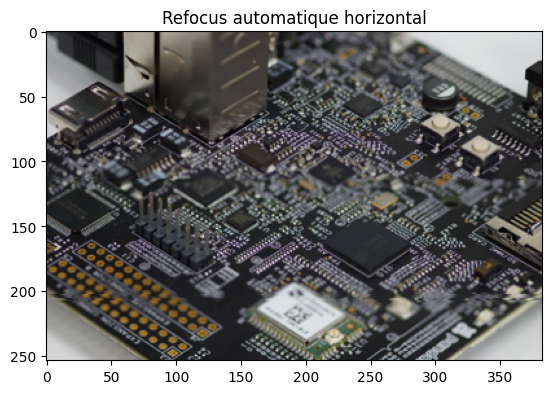

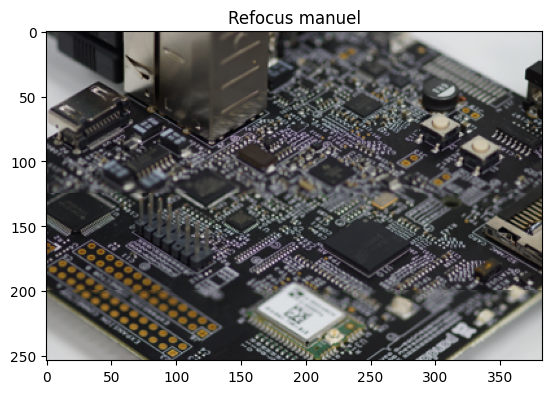

In [2]:
im_refocus_1 = np.array(Image.open("../Images_TP/Refocus_1.png").convert("RGB"))
im_refocus_2 = np.array(Image.open("../Images_TP/Refocus_2.png").convert("RGB"))
im_refocus_3 = np.array(Image.open("../Images_TP/Refocus_3.png").convert("RGB"))
    
im_refocus_1_gray = np.array(Image.open("../Images_TP/Refocus_1.png").convert("L"))
im_refocus_2_gray = np.array(Image.open("../Images_TP/Refocus_2.png").convert("L"))
im_refocus_3_gray = np.array(Image.open("../Images_TP/Refocus_3.png").convert("L"))

affiche_3(im_refocus_1, im_refocus_2, im_refocus_3)

grad = np.abs(filters.laplace((im_refocus_1_gray)))
grad1 = np.abs(filters.laplace((im_refocus_2_gray)))
grad2 = np.abs(filters.laplace((im_refocus_3_gray)))

# grad = filters.sobel(im_refocus_1_gray)
# grad1 = filters.sobel(im_refocus_2_gray)
# grad2 = filters.sobel(im_refocus_3_gray)

affiche_3(grad, grad1, grad2)

fenetre = 4
affiche(refocus(im_refocus_1, im_refocus_2, im_refocus_3, fenetre), title=f"Refocus automatique avec fenetre {fenetre}x{fenetre}")
affiche(refocus_horizontal(im_refocus_1, im_refocus_2, im_refocus_3), title="Refocus automatique horizontal")

# Fait de façon manuel
claire3 = im_refocus_3[:125, :]
claire2 = im_refocus_2[125:200, :]
claire1 = im_refocus_1[200:,:]

# affiche(claire3)
# affiche(claire2)
# affiche(claire1)

new_a = np.zeros_like(im_refocus_1)
new_a[200:,:] = claire1
new_a[125:200, :] = claire2
new_a[:125, :] = claire3
affiche(new_a, title="Refocus manuel")


## Exercice 2

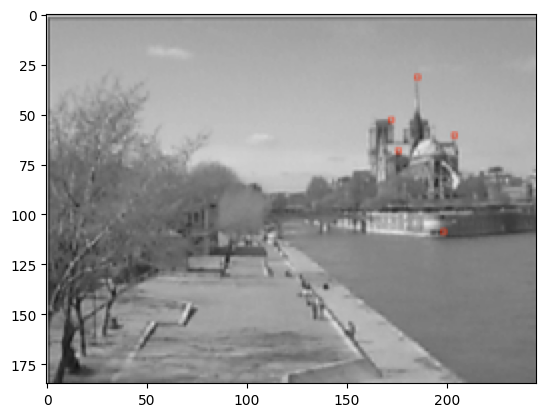

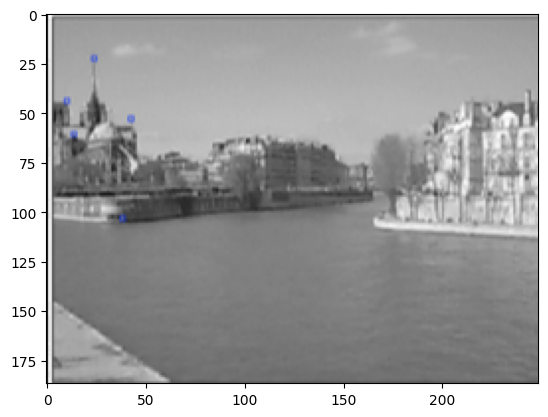

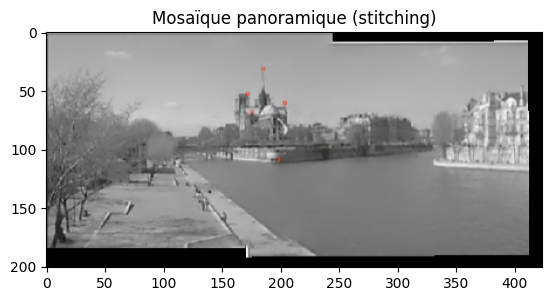

In [3]:
im_mosaic_1 = np.array(Image.open("../Images_TP/Mosaic_1.png").convert("RGB"))
im_mosaic_2 = np.array(Image.open("../Images_TP/Mosaic_2.png").convert("RGB"))

affiche(im_mosaic_1)
affiche(im_mosaic_2)

stitched = mosaic_images([im_mosaic_1, im_mosaic_2])

affiche(stitched, title="Mosaïque panoramique (stitching)")

## Exercice 3

Axe x avant resizing : 574
Axe x après resizing : 444


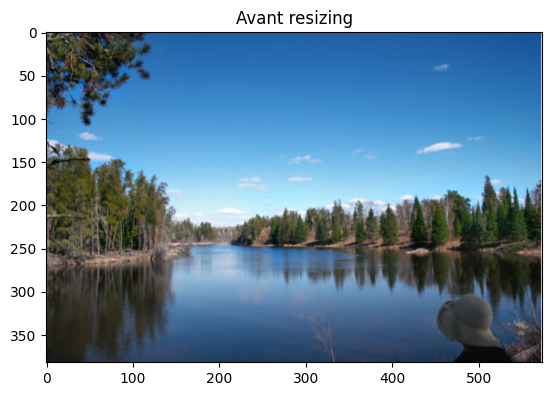

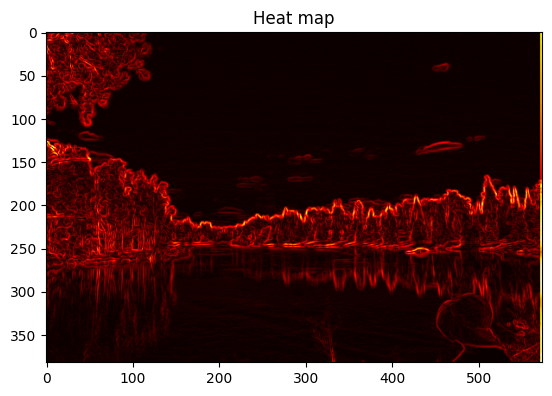

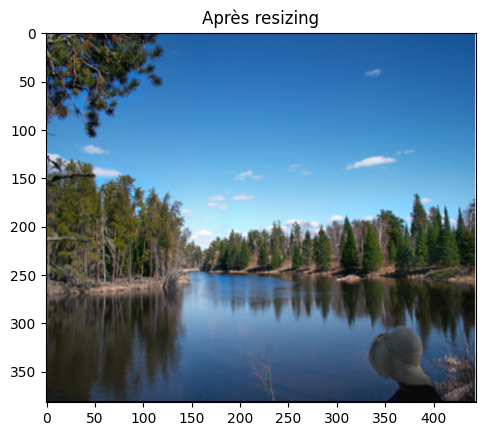

In [4]:
im_resize = np.array(Image.open("../Images_TP/Resize.png").convert("RGB"))
im_resize_gray = np.array(Image.open("../Images_TP/Resize.png").convert("L"))

affiche(im_resize, "Avant resizing")

grad = filters.sobel(im_resize_gray)
plt.figure()
plt.title("Heat map")
plt.imshow(grad, cmap="hot")


im_resized = resizing(im_resize, nb_colonne_retirer = 130, aff_path=False)
affiche(im_resized, "Après resizing")
print("Axe x avant resizing :", len(im_resize[1]))
print("Axe x après resizing :", len(im_resized[1]))

## Exercice 4

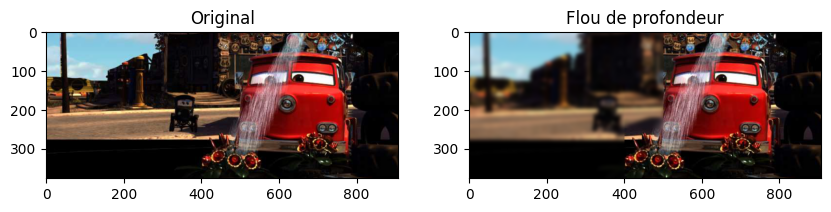

In [5]:
im_profondeur = np.array(Image.open("../Images_TP/Profondeur.png").convert("RGB"))

grad = np.abs(filters.laplace((im_profondeur))) 

new_im = blur_region(im_profondeur, x_start=0, x_end=300, y_start=0, y_end=-1, sigma=5)
new_im = blur_region(im_profondeur, x_start=0, x_end=400, y_start=0, y_end=-1, sigma=5)
new_im = blur_region(new_im, x_start=400, x_end=500, y_start=0, y_end=250, sigma=5)


# Display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(im_profondeur)
plt.subplot(1,2,2)
plt.title("Flou de profondeur")
plt.imshow(new_im)
plt.show()

## Exercice 5

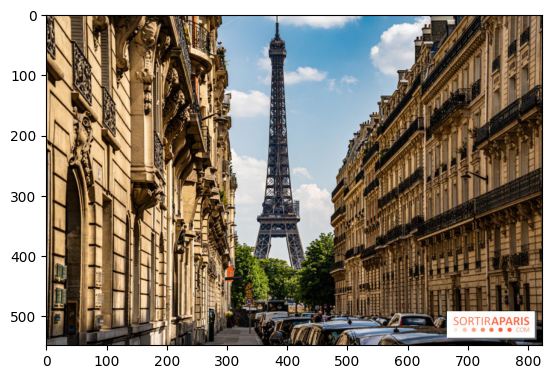

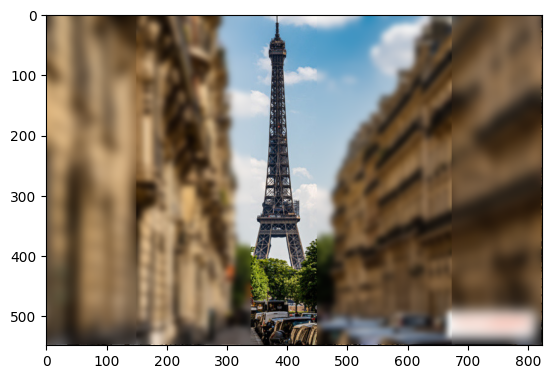

In [6]:
im_tour_eiffel = np.array(Image.open("../Images_TP/tour-eiffel.jpg").convert("RGB"))

affiche(im_tour_eiffel)

affiche(focus_tour_eiffel(im_tour_eiffel))